# 04 - Single-Dataset Latent Simulator

Choose one network dataset, inspect initial-graph descriptor correlations with final p-ratio, train an AE plus latent dynamics model, then evaluate latent readouts and rollout quality.



In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from graph_utils import calc_p_ratio_rollout_sides
from lss.data import load_dataset, resolve_dataset_splits
from lss.graph import clone_graph
from lss.utils import resolve_device

plt.rcParams['figure.dpi'] = 120







/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print('run seed:', seed)

# Choose one: 'reid', 'depablo', or 'noisy'.
selected_dataset = 'depablo'

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../../data/new_reid_combined.pt',
        'train_count': 2,
        'val_count': 20,
    },
    'depablo': {
        'label': 'dePablo OOL',
        'path': '../../data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 1,
        'val_count': 25,
    },
    'noisy': {
        'label': 'Noisy rand OOL',
        'path': '../../data/200_rand_pruned_OOL_bidirect_val1057.pt',
        'train_count': 5,
        'val_count': 20,
    },
}

cfg = {
    'dataset_name': selected_dataset,
    'split_seed': seed,
    'shuffle_dataset_within_source': True,
    'min_train_p_ratio': None,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 8,
    'frame_skip': 1,
    'train_frame_start_order': 1,
    'latent_dim': 1,
    'latent_tokens': 12,
    'hidden_size': 90,
    'edge_feature_dim': 8,
    'ae_max_train_frames_per_sim': 10,
    'dyn_max_train_transitions_per_sim': 10,
    'ae_target_mode': 'delta',
    'node_feature_mode': 'delta',
    'ae_max_epochs': 120,
    'ae_patience': 8,
    'ae_lr': 2e-4,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 120,
    'dyn_patience': 8,
    'dyn_lr': 1e-4,
    'dyn_weight_decay': 1e-5,
    # 'delta' is the historical normalized dz objective.
    # 'next_z' / 'jepa' predicts the next latent embedding directly.
    'propagator_loss': 'delta',
    'propagator_model': None,
    'early_stop_min_delta': 1e-5,
    # 'auto' evaluates every filtered rollout step up to the max available GT length.
    'rollout_steps_grid': [10, 20, 50, 100, 150, 200],
    # Auto rollout evaluates a sparse grid up to the final GT frame.
    # Set to 1 only for small debug runs; full Reid has ~1500 filtered steps.
    'rollout_step_stride': 10,
    'rollout_max_eval_steps': 60,
    'summary_rollout_step': 'max',
    'eval_splits': ['test'],
    'eval_max_sims_per_split': None,
    'show_tables': True,
    'output_root': '../results/latent_space_simulator_single_dataset',
}


def resolve_existing_path(path_like):
    path = Path(path_like)
    if path.exists():
        return str(path)
    if str(path).startswith('../'):
        repo_relative_path = Path(str(path)[3:])
        if repo_relative_path.exists():
            return str(repo_relative_path)
    return str(path)

base_source_spec = dict(dataset_specs[cfg['dataset_name']])
base_source_spec.update({
    'path': resolve_existing_path(base_source_spec['path']),
    'source_name': base_source_spec['label'],
})


source_spec = dict(base_source_spec)
source_spec.update({
    'target_mode': cfg['ae_target_mode'],
    'ae_target_mode': cfg['ae_target_mode'],
    'node_feature_mode': cfg['node_feature_mode'],
    'latent_dim': int(cfg['latent_dim']),
    'repeat_idx': 1,
    'model_seed': int(seed + 1009 * int(cfg['latent_dim'])),
    'latent_tokens': int(cfg['latent_tokens']),
    'hidden_size': int(cfg['hidden_size']),
    'edge_feature_dim': int(cfg['edge_feature_dim']),
    'ae_max_train_frames_per_sim': int(cfg['ae_max_train_frames_per_sim']),
    'dyn_max_train_transitions_per_sim': int(cfg['dyn_max_train_transitions_per_sim']),
    'ae_max_epochs': int(cfg['ae_max_epochs']),
    'ae_patience': int(cfg['ae_patience']),
    'ae_lr': float(cfg['ae_lr']),
    'ae_weight_decay': float(cfg['ae_weight_decay']),
    'dyn_max_epochs': int(cfg['dyn_max_epochs']),
    'dyn_patience': int(cfg['dyn_patience']),
    'dyn_lr': float(cfg['dyn_lr']),
    'dyn_weight_decay': float(cfg['dyn_weight_decay']),
})
source_spec['label'] = f"{base_source_spec['label']} CV{int(cfg['latent_dim'])} {cfg['ae_target_mode']}"


device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root']) / cfg['dataset_name']
run_dir.mkdir(parents=True, exist_ok=True)
print('dataset:', cfg['dataset_name'])
print('path:', base_source_spec['path'])
print('device:', device)
print('output:', run_dir)

SHOW_TABLES = bool(cfg.get('show_tables', True))
try:
    _notebook_display = display
except NameError:
    _notebook_display = None

def display(*args, **kwargs):
    if SHOW_TABLES and _notebook_display is not None:
        return _notebook_display(*args, **kwargs)
    return None

display(pd.DataFrame([source_spec]))





In [3]:
from lss.latent import simulation as latent_sim_utils

safe_linear_fit_1d = latent_sim_utils.safe_linear_fit_1d
r2_score = latent_sim_utils.r2_score
pearson_r = latent_sim_utils.pearson_r
_shared_latent_pratio_corr_rows = latent_sim_utils.latent_pratio_corr_rows


def filtered_frame_ids(sim, *, include_last=False, max_frames=None, start_frame_order=0):
    return latent_sim_utils.filtered_frame_ids(
        sim,
        frame_skip=cfg.get('frame_skip', 1),
        include_last=include_last,
        max_frames=max_frames,
        start_frame_order=start_frame_order,
    )


def frame_for_filtered_step(sim, filtered_step):
    return latent_sim_utils.frame_for_filtered_step(sim, filtered_step, frame_skip=cfg.get('frame_skip', 1))


def make_frame_index(sims, *, max_frames_per_sim=None, include_last=False, start_frame_order=0):
    return latent_sim_utils.make_frame_index(
        sims,
        frame_skip=cfg.get('frame_skip', 1),
        max_frames_per_sim=max_frames_per_sim,
        include_last=include_last,
        start_frame_order=start_frame_order,
    )


def make_transition_index(sims, *, max_frames_per_sim=None):
    return latent_sim_utils.make_transition_index(
        sims,
        frame_skip=cfg.get('frame_skip', 1),
        max_frames_per_sim=max_frames_per_sim,
    )


def max_filtered_rollout_steps(sims):
    # Common GT horizon for the evaluated split; avoids asking for rollout steps
    # that only some trajectories can support.
    if not sims:
        return 0
    return min(max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0) for sim in sims)


def rollout_steps_for_sims(sims):
    grid = cfg.get('rollout_steps_grid', 'auto')
    max_steps = max_filtered_rollout_steps(sims)
    if max_steps <= 0:
        return []
    if isinstance(grid, str) and grid == 'auto':
        stride = max(1, int(cfg.get('rollout_step_stride', 25)))
        steps = list(range(stride, max_steps + 1, stride))
        if not steps or steps[-1] != max_steps:
            steps.append(max_steps)
        max_eval_steps = cfg.get('rollout_max_eval_steps')
        if max_eval_steps is not None and len(steps) > int(max_eval_steps):
            keep = np.linspace(0, len(steps) - 1, int(max_eval_steps), dtype=int)
            steps = [steps[int(idx)] for idx in keep]
            if steps[-1] != max_steps:
                steps[-1] = max_steps
        return sorted(set(int(step) for step in steps))
    return sorted({min(int(step), max_steps) for step in grid if min(int(step), max_steps) > 0})


def iter_batches(rows, batch_graphs, *, shuffle=True):
    return latent_sim_utils.iter_batches(rows, batch_graphs, shuffle=shuffle)


def edge_features(ref_graph, cur_graph, *, device):
    return latent_sim_utils.edge_features(ref_graph, cur_graph, pos_dim=cfg['pos_dim'], device=device)


def frame_node_feature(sim, t, *, mode, device):
    return latent_sim_utils.frame_node_feature(sim, t, pos_dim=cfg['pos_dim'], mode=mode, device=device)


def batch_delta_graphs(sims, rows, *, device, node_feature_mode='delta'):
    return latent_sim_utils.batch_delta_graphs(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        device=device,
        node_feature_mode=node_feature_mode,
    )


def ae_target_tensor(batch_data, target_mode):
    return latent_sim_utils.ae_target_tensor(batch_data, target_mode)


def fit_ae_target_stats(sims, rows, *, device, target_mode):
    return latent_sim_utils.fit_ae_target_stats(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        batch_graphs=cfg['batch_graphs'],
        device=device,
        target_mode=target_mode,
    )


def fit_node_feature_stats(sims, rows, *, device, node_feature_mode):
    return latent_sim_utils.fit_node_feature_stats(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        batch_graphs=cfg['batch_graphs'],
        device=device,
        node_feature_mode=node_feature_mode,
    )


def fit_edge_stats(sims, rows, *, device):
    return latent_sim_utils.fit_edge_stats(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        batch_graphs=cfg['batch_graphs'],
        device=device,
    )


def normalize_ae_target(target):
    return (target - target_mean) / target_std


def unnormalize_ae_target(target_norm):
    return target_norm * target_std + target_mean


def normalize_delta(delta):
    return normalize_ae_target(delta)


def unnormalize_delta(delta_norm):
    return unnormalize_ae_target(delta_norm)


def normalize_node_feature(node_feature):
    return (node_feature - node_feature_mean) / node_feature_std


def normalize_edge_attr(edge_attr):
    return (edge_attr - edge_mean) / edge_std






In [4]:
from lss.latent.models import (
    NodeDeltaAttentionAutoEncoder,
    make_latent_propagator,
)



from lss.latent import training as latent_train_utils





In [5]:
def encode_frame(model, sim, t, *, device):
    ref_graph = sim[0]
    cur_graph = sim[int(t)]
    ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
    node_feature = frame_node_feature(sim, t, mode=node_feature_mode, device=device)
    node_feature_norm = normalize_node_feature(node_feature)
    edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, cur_graph, device=device))
    ref_edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, ref_graph, device=device))
    edge_index = ref_graph.edge_index.to(device).long()
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    z, _ = model.encode(node_feature_norm, ref_pos, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
    return z.squeeze(0)


def encode_transition_batch(model, sims, rows, *, device):
    z0 = []
    z1 = []
    with torch.no_grad():
        for row in rows:
            if len(row) == 3:
                sim_idx, t0, t1 = row
            else:
                sim_idx, t0 = row
                t1 = int(t0) + 1
            sim = sims[int(sim_idx)]
            z0.append(encode_frame(model, sim, int(t0), device=device))
            z1.append(encode_frame(model, sim, int(t1), device=device))
    return torch.stack(z0, dim=0), torch.stack(z1, dim=0)


def fit_latent_step_stats(model, sims, rows, *, device):
    z_chunks = []
    z_next_chunks = []
    dz_chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        z0, z1 = encode_transition_batch(model, sims, rows_batch, device=device)
        z_chunks.append(z0.detach())
        z_next_chunks.append(z1.detach())
        dz_chunks.append((z1 - z0).detach())
    z_all = torch.cat(z_chunks, dim=0)
    z_next_all = torch.cat(z_next_chunks, dim=0)
    dz_all = torch.cat(dz_chunks, dim=0)
    return {
        'z_mean': z_all.mean(dim=0, keepdim=True),
        'z_std': z_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
        'dz_mean': dz_all.mean(dim=0, keepdim=True),
        'dz_std': dz_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
        'z_next_mean': z_next_all.mean(dim=0, keepdim=True),
        'z_next_std': z_next_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
    }


def normalize_z(z):
    return (z - latent_stats['z_mean']) / latent_stats['z_std']


def normalize_dz(dz):
    return (dz - latent_stats['dz_mean']) / latent_stats['dz_std']


def unnormalize_dz(dz_norm):
    return dz_norm * latent_stats['dz_std'] + latent_stats['dz_mean']


def normalize_z_next(z):
    return (z - latent_stats.get('z_next_mean', latent_stats['z_mean'])) / latent_stats.get('z_next_std', latent_stats['z_std'])


def unnormalize_z_next(z_norm):
    return z_norm * latent_stats.get('z_next_std', latent_stats['z_std']) + latent_stats.get('z_next_mean', latent_stats['z_mean'])


def latent_step(model, z):
    loss_mode = str(globals().get('propagator_loss_mode', cfg.get('propagator_loss', 'delta'))).lower()
    z_norm = normalize_z(z.unsqueeze(0))
    pred = model(z_norm)
    if loss_mode in {'next_z', 'jepa', 'next_embedding'}:
        return unnormalize_z_next(pred).squeeze(0)
    pred_dz_norm = pred - z_norm
    return z + unnormalize_dz(pred_dz_norm).squeeze(0)


def decode_latent_to_graph(ae_model, sim, z, target_index, *, device):
    ref = clone_graph(sim[0]).to(device)
    ref_pos = ref.x[:, :cfg['pos_dim']].float()
    ref_edge_attr_norm = normalize_edge_attr(edge_features(sim[0], sim[0], device=device))
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    h0 = ae_model.encode_reference_graph(ref_pos, ref_edge_attr_norm, ref.edge_index.to(device).long())
    target_norm = ae_model.decode(z.unsqueeze(0), h0, batch)
    target = unnormalize_ae_target(target_norm)
    pred = clone_graph(sim[target_index]).to(device)
    pred.x = pred.x.clone().float()
    if ae_target_mode in ('position', 'positions'):
        pred.x[:, :cfg['pos_dim']] = target
    else:
        pred.x[:, :cfg['pos_dim']] = ref_pos + target
    return pred.cpu()







In [ ]:
def p_ratio_metrics(df, *, dataset, split_name, rollout_steps):
    if len(df) == 0:
        return {'dataset': dataset, 'split': split_name, 'rollout_steps': rollout_steps, 'used': 0}
    return {
        'dataset': dataset,
        'split': split_name,
        'rollout_steps': int(rollout_steps),
        'used': len(df),
        'p_ratio_r2': r2_score(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_pearson': pearson_r(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_mse': float(np.mean((df['true_p_ratio'] - df['pred_p_ratio']) ** 2)),
        'final_pos_mse': float(df['final_pos_mse'].mean()),
        'initial_to_target_mse': float(df['initial_to_target_mse'].mean()),
        'pred_to_initial_mse': float(df['pred_to_initial_mse'].mean()),
        'movement_fraction_mse': float(df['movement_fraction_mse'].mean()),
    }


def latent_rollout_eval(ae_model, dyn_model, sims, *, dataset, split_name, rollout_steps):
    rows = []
    ae_model.eval(); dyn_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            filtered_steps = min(int(rollout_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
            target_index = frame_for_filtered_step(sim, filtered_steps)
            if filtered_steps <= 0 or target_index <= 0:
                continue
            z0 = encode_frame(ae_model, sim, 0, device=device)
            z = z0.clone()
            for _ in range(filtered_steps):
                z = latent_step(dyn_model, z)
            pred_graph = decode_latent_to_graph(ae_model, sim, z, target_index, device=device)
            pred_pr = float(calc_p_ratio_rollout_sides([clone_graph(sim[0]).cpu(), pred_graph], -1))
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            initial_pos = sim[0].x[:, :cfg['pos_dim']].cpu().float()
            target_pos = sim[target_index].x[:, :cfg['pos_dim']].cpu().float()
            pred_pos = pred_graph.x[:, :cfg['pos_dim']].cpu().float()
            initial_to_target_mse = float(F.mse_loss(initial_pos, target_pos).item())
            pred_to_initial_mse = float(F.mse_loss(pred_pos, initial_pos).item())
            rows.append({
                'dataset': dataset,
                'split': split_name,
                'sim_idx': sim_idx,
                'target_index': target_index,
                'rollout_steps': int(rollout_steps),
                'filtered_steps': int(filtered_steps),
                'pred_p_ratio': pred_pr,
                'true_p_ratio': true_pr,
                'final_pos_mse': float(F.mse_loss(pred_pos, target_pos).item()),
                'initial_to_target_mse': initial_to_target_mse,
                'pred_to_initial_mse': pred_to_initial_mse,
                'movement_fraction_mse': pred_to_initial_mse / initial_to_target_mse if initial_to_target_mse > 0 else float('nan'),
            })
    df = pd.DataFrame(rows)
    return df, p_ratio_metrics(df, dataset=dataset, split_name=split_name, rollout_steps=rollout_steps)





In [ ]:
def resolve_p_ratio_filtered_train_split(source_spec, p):
    min_train_p_ratio = p.get('min_train_p_ratio')
    if min_train_p_ratio is None:
        return resolve_dataset_splits(
            source_spec['path'],
            train_count=p['train_count'],
            val_count=p['val_count'],
            split_seed=cfg['split_seed'],
            shuffle_within_source=cfg.get('shuffle_dataset_within_source', False),
        )

    sims = load_dataset(source_spec['path'])
    if cfg.get('shuffle_dataset_within_source', False):
        generator = torch.Generator()
        generator.manual_seed(0 if cfg['split_seed'] is None else int(cfg['split_seed']))
        order = torch.randperm(len(sims), generator=generator).tolist()
        sims = [sims[i] for i in order]

    p_ratios = [float(calc_p_ratio_rollout_sides(sim, -1)) for sim in sims]
    train_count = int(p['train_count'])
    val_count = int(p['val_count'])
    eligible_indices = [idx for idx, pr in enumerate(p_ratios) if pr > float(min_train_p_ratio)]
    if len(eligible_indices) < train_count:
        raise ValueError(
            f"Only {len(eligible_indices)} networks have final p-ratio > {min_train_p_ratio}; "
            f"need train_count={train_count}."
        )

    train_indices = set(eligible_indices[:train_count])
    train_data = [sims[idx] for idx in range(len(sims)) if idx in train_indices]
    holdout_data = [sim for idx, sim in enumerate(sims) if idx not in train_indices]
    val_data = holdout_data[:val_count]
    test_data = holdout_data[val_count:]
    train_pr = [p_ratios[idx] for idx in train_indices]
    split_info = [{
        'source': Path(source_spec['path']).stem,
        'path': str(source_spec['path']),
        'total': len(sims),
        'eligible_train': len(eligible_indices),
        'min_train_p_ratio': float(min_train_p_ratio),
        'train': len(train_data),
        'val': len(val_data),
        'test': len(test_data),
        'train_p_ratio_min': float(np.min(train_pr)) if train_pr else float('nan'),
        'train_p_ratio_max': float(np.max(train_pr)) if train_pr else float('nan'),
    }]
    return train_data, val_data, test_data, split_info


def train_one_source(source_spec):
    global target_mean, target_std, delta_mean, delta_std, node_feature_mean, node_feature_std, edge_mean, edge_std, latent_stats, node_feature_mode, ae_target_mode, propagator_loss_mode

    label = source_spec['label']
    p = {**cfg, **source_spec}
    print(f"\n=== {label} ===")
    train_data, val_data, test_data, split_info = resolve_p_ratio_filtered_train_split(source_spec, p)
    print(pd.DataFrame(split_info).to_string(index=False))

    node_feature_mode = p.get('node_feature_mode', 'delta')
    ae_target_mode = p.get('ae_target_mode', 'delta')
    print('node_feature_mode:', node_feature_mode, 'ae_target_mode:', ae_target_mode)
    ae_frame_budget = int(p['ae_max_train_frames_per_sim'])
    dyn_transition_budget = int(p['dyn_max_train_transitions_per_sim'])
    print(
        'frame_skip:', cfg.get('frame_skip', 1),
        'AE train frames/sim:', ae_frame_budget,
        'dynamics train transitions/sim:', dyn_transition_budget,
    )
    train_frames = make_frame_index(
        train_data,
        max_frames_per_sim=ae_frame_budget,
        include_last=True,
        start_frame_order=p.get('train_frame_start_order', 0),
    )
    val_frames = make_frame_index(
        val_data,
        max_frames_per_sim=ae_frame_budget,
        include_last=True,
        start_frame_order=p.get('train_frame_start_order', 0),
    )
    target_mean, target_std = fit_ae_target_stats(train_data, train_frames, device=device, target_mode=ae_target_mode)
    delta_mean, delta_std = target_mean, target_std
    node_feature_mean, node_feature_std = fit_node_feature_stats(train_data, train_frames, device=device, node_feature_mode=node_feature_mode)
    edge_mean, edge_std = fit_edge_stats(train_data, train_frames, device=device)
    p['edge_feature_dim'] = int(edge_mean.numel())
    print('edge_feature_dim:', p['edge_feature_dim'])

    ae_model = NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'], edge_dim=p['edge_feature_dim'], hidden_size=p['hidden_size'],
        latent_dim=p['latent_dim'], latent_tokens=p['latent_tokens'],
    ).to(device)
    shared_normalizers = {
        'target_mean': target_mean,
        'target_std': target_std,
        'node_feature_mean': node_feature_mean,
        'node_feature_std': node_feature_std,
        'edge_mean': edge_mean,
        'edge_std': edge_std,
    }
    print('autoencoder')
    ae_result = latent_train_utils.train_autoencoder(
        ae_model,
        train_data,
        val_data,
        train_frames,
        val_frames,
        batch_graphs=cfg['batch_graphs'],
        pos_dim=cfg['pos_dim'],
        node_feature_mode=node_feature_mode,
        ae_target_mode=ae_target_mode,
        normalizers=shared_normalizers,
        device=device,
        config=latent_train_utils.TrainingConfig(
            max_epochs=p['ae_max_epochs'],
            patience=p['ae_patience'],
            learning_rate=p['ae_lr'],
            weight_decay=p.get('ae_weight_decay', 1e-5),
            min_delta=cfg['early_stop_min_delta'],
            log_every=10,
        ),
    )
    ae_model = ae_result.model
    ae_history = ae_result.history.rename(columns={
        'train_loss': 'train_mse_norm',
        'val_loss': 'val_mse_norm',
    }).assign(
        dataset=label,
        latent_dim=p['latent_dim'],
        target_mode=ae_target_mode,
        hidden_size=p['hidden_size'],
    ).to_dict('records')
    for param in ae_model.parameters():
        param.requires_grad_(False)

    train_steps = make_transition_index(train_data, max_frames_per_sim=dyn_transition_budget)
    val_steps = make_transition_index(val_data, max_frames_per_sim=dyn_transition_budget)
    latent_stats = fit_latent_step_stats(ae_model, train_data, train_steps, device=device)
    propagator_loss_mode = str(p.get('propagator_loss', cfg.get('propagator_loss', 'delta'))).lower()
    dyn_model = make_latent_propagator(
        p['latent_dim'],
        p['hidden_size'],
        model_type=p.get('propagator_model') or ('direct_mlp' if propagator_loss_mode in {'next_z', 'jepa', 'next_embedding'} else 'residual_mlp'),
    ).to(device)
    print('latent propagator')
    dyn_result = latent_train_utils.train_propagator(
        dyn_model,
        ae_model,
        train_data,
        val_data,
        train_steps,
        val_steps,
        latent_stats,
        batch_graphs=cfg['batch_graphs'],
        pos_dim=cfg['pos_dim'],
        node_feature_mode=node_feature_mode,
        normalizers=shared_normalizers,
        device=device,
        loss_mode=propagator_loss_mode,
        objective='one_step',
        config=latent_train_utils.TrainingConfig(
            max_epochs=p['dyn_max_epochs'],
            patience=p['dyn_patience'],
            learning_rate=p['dyn_lr'],
            weight_decay=p.get('dyn_weight_decay', 1e-5),
            min_delta=cfg['early_stop_min_delta'],
            log_every=10,
        ),
    )
    dyn_model = dyn_result.model
    dyn_history = dyn_result.history.rename(columns={
        'train_loss_norm': 'train_dz_mse_norm',
        'val_loss_norm': 'val_dz_mse_norm',
        'val_loss_raw': 'val_dz_mse_raw',
    }).assign(
        dataset=label,
        latent_dim=p['latent_dim'],
        target_mode=ae_target_mode,
        hidden_size=p['hidden_size'],
        propagator_loss=propagator_loss_mode,
    ).to_dict('records')

    rollout_rows = []
    rollout_stats = []
    eval_split_map = {'train': train_data, 'val': val_data, 'test': test_data}
    eval_splits = cfg.get('eval_splits', ['test'])
    max_eval_sims = cfg.get('eval_max_sims_per_split')
    for split_name in eval_splits:
        sims = eval_split_map[split_name]
        if max_eval_sims is not None:
            sims = sims[:int(max_eval_sims)]
        steps_grid = rollout_steps_for_sims(sims)
        print(f'rollout eval split={split_name}: {len(steps_grid)} steps up to {max(steps_grid) if steps_grid else 0}')
        for steps in steps_grid:
            df, stats = latent_rollout_eval(ae_model, dyn_model, sims, dataset=label, split_name=split_name, rollout_steps=steps)
            rollout_rows.append(df)
            rollout_stats.append(stats)

    rollout_rows_df = pd.concat(rollout_rows, ignore_index=True) if rollout_rows else pd.DataFrame()
    rollout_stats_df = pd.DataFrame(rollout_stats)

    return {
        'label': label,
        'params': p,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data,
        'ae': ae_model,
        'dyn': dyn_model,
        'stats': {k: v.detach().cpu() if torch.is_tensor(v) else v for k, v in {'target_mean': target_mean, 'target_std': target_std, 'delta_mean': delta_mean, 'delta_std': delta_std, 'node_feature_mean': node_feature_mean, 'node_feature_std': node_feature_std, 'edge_mean': edge_mean, 'edge_std': edge_std, 'ae_target_mode': ae_target_mode, **latent_stats}.items()},
        'ae_history': pd.DataFrame(ae_history),
        'dyn_history': pd.DataFrame(dyn_history),
        'rollout_rows': rollout_rows_df,
        'rollout_stats': rollout_stats_df,
    }



## Initial Descriptor Correlations


count    100.000000
mean      -0.091587
std        0.293367
min       -0.573460
25%       -0.386325
50%       -0.068524
75%        0.162498
max        0.408445


,feature,pearson_r,spearman_r,n
4,stiffness_std,-0.9342,-0.9315,100
5,stiffness_min,0.9342,0.9346,100
7,length_mean,-0.7818,-0.7852,100
3,stiffness_mean,0.7215,0.7181,100
9,length_min,0.7164,0.6365,100
6,stiffness_max,-0.6561,-0.6362,100
13,stiffness_length_corr,0.5527,0.5582,100
10,length_max,0.1337,0.1278,100
8,length_std,-0.0752,-0.0816,100
0,frames,0.0594,0.0528,100


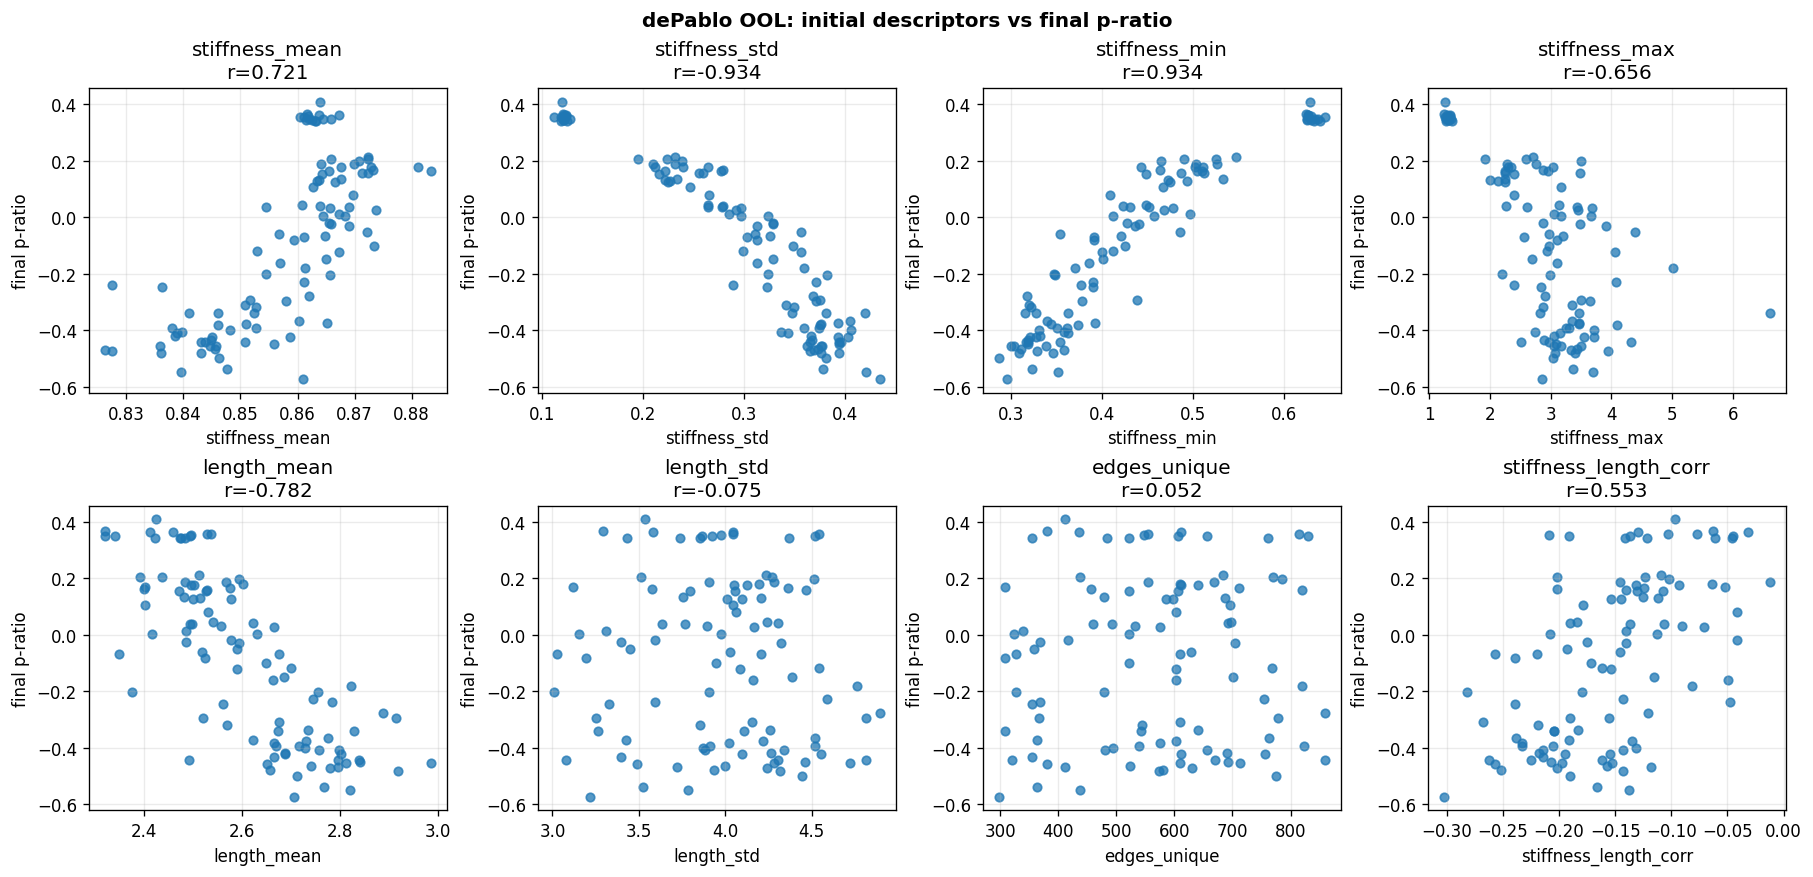

In [8]:
def unique_initial_edges(sim):
    graph = sim[0]
    pos = graph.x[:, :cfg['pos_dim']].detach().cpu().float().numpy()
    edge_index = graph.edge_index.detach().cpu().numpy()
    edge_attr = graph.edge_attr.detach().cpu().float().numpy()
    rows = {}
    for edge_idx in range(edge_index.shape[1]):
        i, j = int(edge_index[0, edge_idx]), int(edge_index[1, edge_idx])
        if i == j:
            continue
        key = tuple(sorted((i, j)))
        if key in rows:
            continue
        vec = pos[j] - pos[i]
        length = float(np.linalg.norm(vec))
        stiffness = float(edge_attr[edge_idx, -1]) if edge_attr.shape[1] else np.nan
        rows[key] = {
            'i': key[0],
            'j': key[1],
            'length': length,
            'stiffness': stiffness,
            'dx': float(vec[0]),
            'dy': float(vec[1]) if vec.shape[0] > 1 else 0.0,
        }
    return pd.DataFrame(rows.values())


def initial_graph_descriptors(sim, sim_idx):
    edges = unique_initial_edges(sim)
    if edges.empty:
        edge_values = pd.Series(dtype=float)
        lengths = pd.Series(dtype=float)
    else:
        edge_values = edges['stiffness'].astype(float)
        lengths = edges['length'].astype(float)
    row = {
        'sim_idx': int(sim_idx),
        'frames': int(len(sim)),
        'nodes': int(sim[0].x.shape[0]),
        'edges_unique': int(len(edges)),
        'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
        'stiffness_mean': float(edge_values.mean()) if len(edge_values) else np.nan,
        'stiffness_std': float(edge_values.std(ddof=0)) if len(edge_values) else np.nan,
        'stiffness_min': float(edge_values.min()) if len(edge_values) else np.nan,
        'stiffness_max': float(edge_values.max()) if len(edge_values) else np.nan,
        'length_mean': float(lengths.mean()) if len(lengths) else np.nan,
        'length_std': float(lengths.std(ddof=0)) if len(lengths) else np.nan,
        'length_min': float(lengths.min()) if len(lengths) else np.nan,
        'length_max': float(lengths.max()) if len(lengths) else np.nan,
    }
    if not edges.empty:
        theta = np.arctan2(edges['dy'].to_numpy(float), edges['dx'].to_numpy(float))
        row['abs_cos_mean'] = float(np.mean(np.abs(np.cos(theta))))
        row['abs_sin_mean'] = float(np.mean(np.abs(np.sin(theta))))
        row['stiffness_length_corr'] = float(edges[['stiffness', 'length']].corr().iloc[0, 1]) if edges['stiffness'].std(ddof=0) > 0 and edges['length'].std(ddof=0) > 0 else np.nan
    else:
        row['abs_cos_mean'] = np.nan
        row['abs_sin_mean'] = np.nan
        row['stiffness_length_corr'] = np.nan
    return row


all_sims = load_dataset(source_spec['path'])
descriptor_df = pd.DataFrame([initial_graph_descriptors(sim, idx) for idx, sim in enumerate(all_sims)])
descriptor_df.to_csv(run_dir / 'initial_descriptor_table.csv', index=False)

corr_rows = []
for col in descriptor_df.columns:
    if col in {'sim_idx', 'final_p_ratio'}:
        continue
    clean = descriptor_df[[col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
    if len(clean) >= 3 and clean[col].std(ddof=0) > 0 and clean['final_p_ratio'].std(ddof=0) > 0:
        corr_rows.append({
            'feature': col,
            'pearson_r': float(clean[col].corr(clean['final_p_ratio'], method='pearson')),
            'spearman_r': float(clean[col].corr(clean['final_p_ratio'], method='spearman')),
            'n': int(len(clean)),
        })
descriptor_corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r', key=lambda s: s.abs(), ascending=False)
descriptor_corr_df.to_csv(run_dir / 'initial_descriptor_correlations.csv', index=False)

print(descriptor_df['final_p_ratio'].describe().to_string())
display(descriptor_corr_df.round(4))

plot_features = [
    'stiffness_mean', 'stiffness_std', 'stiffness_min', 'stiffness_max',
    'length_mean', 'length_std', 'edges_unique', 'stiffness_length_corr',
]
plot_features = [f for f in plot_features if f in descriptor_df.columns]
fig, axes = plt.subplots(2, 4, figsize=(15, 7.2), squeeze=False, constrained_layout=True)
for ax, feature in zip(axes.ravel(), plot_features):
    clean = descriptor_df[[feature, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
    ax.scatter(clean[feature], clean['final_p_ratio'], s=26, alpha=0.75)
    r = clean[feature].corr(clean['final_p_ratio']) if len(clean) > 2 else np.nan
    ax.set_title(f'{feature}\nr={r:.3f}')
    ax.set_xlabel(feature)
    ax.set_ylabel('final p-ratio')
    ax.grid(alpha=0.25)
for ax in axes.ravel()[len(plot_features):]:
    ax.axis('off')
fig.suptitle(f'{base_source_spec["label"]}: initial descriptors vs final p-ratio', fontweight='bold')
fig.savefig(run_dir / 'initial_descriptor_scatter.png', dpi=200, bbox_inches='tight')
plt.show()




## Train AE And Latent Dynamics


In [ ]:
run_seed = int(source_spec['model_seed'])
random.seed(run_seed)
np.random.seed(run_seed % (2**32 - 1))
torch.manual_seed(run_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(run_seed)

result = train_one_source(source_spec)
source_results = [result]


def add_result_metadata(df, result):
    df = df.copy()
    df['latent_dim'] = int(result['params']['latent_dim'])
    df['repeat_idx'] = int(result['params'].get('repeat_idx', 1))
    df['model_seed'] = int(result['params'].get('model_seed', seed))
    df['run_label'] = result['label']
    return df


ae_history_df = pd.concat([add_result_metadata(r['ae_history'], r) for r in source_results], ignore_index=True)
dyn_history_df = pd.concat([add_result_metadata(r['dyn_history'], r) for r in source_results], ignore_index=True)
rollout_rows_df = pd.concat([add_result_metadata(r['rollout_rows'], r) for r in source_results], ignore_index=True)
rollout_stats_df = pd.concat([add_result_metadata(r['rollout_stats'], r) for r in source_results], ignore_index=True)
ae_history_df.to_csv(run_dir / 'ae_history.csv', index=False)
dyn_history_df.to_csv(run_dir / 'dyn_history.csv', index=False)
rollout_rows_df.to_csv(run_dir / 'rollout_rows.csv', index=False)
rollout_stats_df.to_csv(run_dir / 'rollout_stats.csv', index=False)
n_loss_cols = 2
fig, axes = plt.subplots(1, n_loss_cols, figsize=(6 * n_loss_cols, 4.2), constrained_layout=True)
axes = np.atleast_1d(axes)
for _, group in ae_history_df.groupby('run_label'):
    mean_group = group.sort_values('epoch')
    axes[0].plot(mean_group['epoch'], mean_group['val_mse_norm'], lw=1.8, label=result['label'])
axes[0].set_title('AE validation reconstruction')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('normalized MSE')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=8)
for _, group in dyn_history_df.groupby('run_label'):
    mean_group = group.sort_values('epoch')
    axes[1].plot(mean_group['epoch'], mean_group['val_dz_mse_norm'], lw=1.8, label=result['label'])
axes[1].set_title('One-step latent propagator validation')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('normalized dz MSE')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False, fontsize=8)
fig.savefig(run_dir / 'training_losses.png', dpi=200, bbox_inches='tight')
plt.show()

display(rollout_stats_df.round(5))




## Latent Correlations


,latent_dim,split,latent,target,pearson_r,spearman_r,n,abs_pearson_r
0,1,test,z0,final_p_ratio,0.9797,0.9553,74,0.9797
1,1,val,z0,final_p_ratio,0.9728,0.9492,25,0.9728


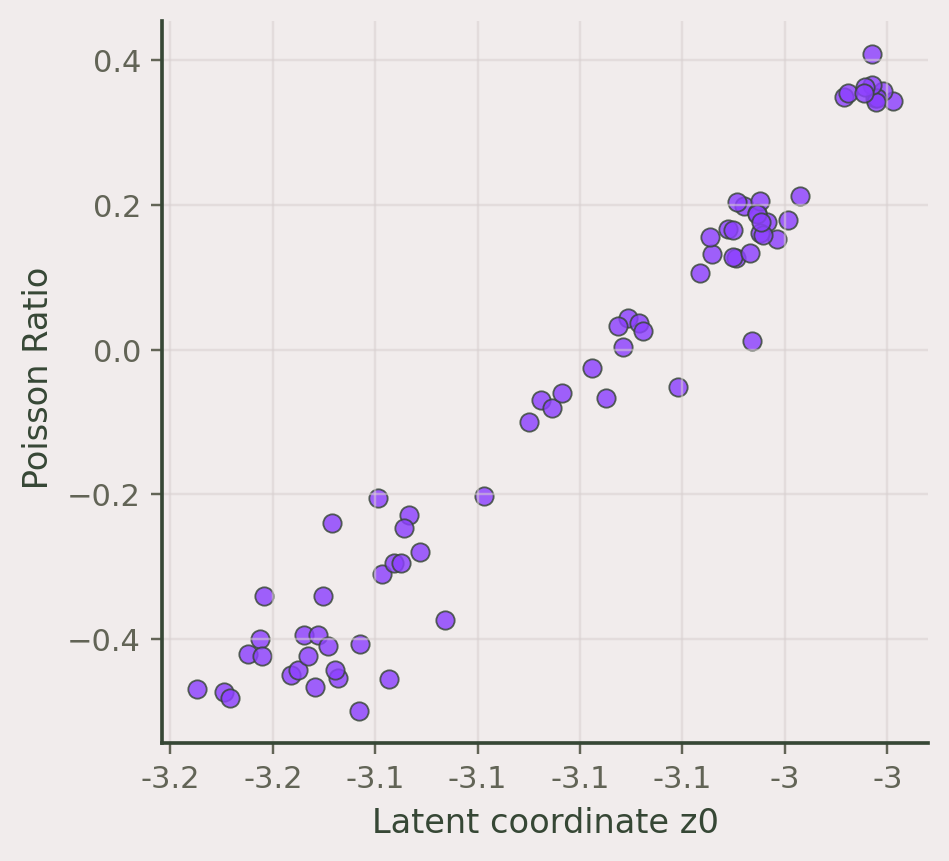

In [16]:
def latent_table_for_split(result, sims, split_name):
    rows = []
    ae_model = result['ae']
    latent_dim = int(result['params']['latent_dim'])
    repeat_idx = int(result['params'].get('repeat_idx', 1))

    ae_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            z = encode_frame(ae_model, sim, 0, device=device).detach().cpu().numpy().reshape(-1)
            desc = initial_graph_descriptors(sim, sim_idx)

            row = {
                'split': split_name,
                'latent_dim': latent_dim,
                'repeat_idx': repeat_idx,
                'run_label': result['label'],
                **desc,
            }

            for dim_idx, value in enumerate(z):
                row[f'z{dim_idx}'] = float(value)

            rows.append(row)

    return pd.DataFrame(rows)


latent_df = pd.concat([
    table
    for result_item in source_results
    for table in [
        latent_table_for_split(result_item, result_item['train_data'], 'train'),
        latent_table_for_split(result_item, result_item['val_data'], 'val'),
        latent_table_for_split(result_item, result_item['test_data'], 'test'),
    ]
], ignore_index=True)

latent_df.to_csv(run_dir / 'initial_latent_table.csv', index=False)


latent_corr_rows = []

for (latent_dim, split_name), split_df in latent_df.groupby(['latent_dim', 'split']):
    z_cols = [
        col for col in split_df.columns
        if col.startswith('z') and split_df[col].notna().any()
    ]

    for z_col in z_cols:
        clean = split_df[[z_col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()

        if (
            len(clean) >= 3
            and clean[z_col].std(ddof=0) > 0
            and clean['final_p_ratio'].std(ddof=0) > 0
        ):
            latent_corr_rows.append({
                'latent_dim': int(latent_dim),
                'split': split_name,
                'latent': z_col,
                'target': 'final_p_ratio',
                'pearson_r': float(clean[z_col].corr(clean['final_p_ratio'])),
                'spearman_r': float(clean[z_col].corr(clean['final_p_ratio'], method='spearman')),
                'n': int(len(clean)),
            })


latent_corr_df = pd.DataFrame(latent_corr_rows)

if not latent_corr_df.empty:
    latent_corr_df['abs_pearson_r'] = latent_corr_df['pearson_r'].abs()
    latent_corr_df = latent_corr_df.sort_values(
        ['split', 'latent_dim', 'abs_pearson_r'],
        ascending=[True, True, False],
    )

latent_corr_df.to_csv(run_dir / 'initial_latent_p_ratio_correlations.csv', index=False)
display(latent_corr_df.round(4))


THEME = {
    'bg': '#f1ecec',
    'text': '#364735',
    'muted': '#626456',
    'axis': '#364735',
    'grid': '#d8d0d0',
    'purple': '#8C40FE',
    'green': '#545B4C',
}


best_test = (
    latent_corr_df[latent_corr_df['split'].eq('test')].drop_duplicates('latent_dim')
    if not latent_corr_df.empty
    else pd.DataFrame()
)

if not best_test.empty:
    n_plots = len(best_test)

    fig, axes = plt.subplots(
        1,
        n_plots,
        figsize=(4.2 * n_plots, 3.8),
        squeeze=False,
        constrained_layout=True,
        facecolor=THEME['bg'],
        dpi=220
    )

    for ax, (_, row) in zip(axes.ravel(), best_test.iterrows()):
        latent_dim = int(row['latent_dim'])
        z_col = row['latent']

        sub = latent_df[
            latent_df['latent_dim'].eq(latent_dim)
            & latent_df['split'].eq('test')
        ]

        ax.set_facecolor(THEME['bg'])

        ax.scatter(
            sub[z_col],
            sub['final_p_ratio'],
            s=36,
            alpha=0.82,
            color=THEME['purple'],
            edgecolor=THEME['text'],
            linewidth=0.6,
        )

        # ax.set_title(
        #     f'CV{latent_dim}: {z_col}\nr = {row["pearson_r"]:.3f}',
        #     color=THEME['text'],
        #     fontsize=12,
        #     fontweight='bold',
        #     pad=10,
        # )

        ax.set_xlabel(f'Latent coordinate {z_col}', color=THEME['text'], fontsize=11)
        ax.set_ylabel(' Poisson Ratio', color=THEME['text'], fontsize=11)

        ax.tick_params(axis='both', colors=THEME['muted'], labelsize=10)

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

        ax.spines['left'].set_color(THEME['axis'])
        ax.spines['bottom'].set_color(THEME['axis'])
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)

        ax.grid(True, color=THEME['grid'], linewidth=0.8, alpha=0.55)

    # fig.suptitle(
    #     'Latent coordinates associated with final p-ratio',
    #     color=THEME['text'],
    #     fontsize=15,
    #     fontweight='bold',
    # )
    from matplotlib.ticker import FormatStrFormatter

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    plt.show()


## Framewise Latent Readouts

The previous cell uses only the initial latent state. This cell checks whether later latent states still encode final p-ratio, and whether the latent state also encodes where the frame is along the trajectory.



framewise latent rows: (9999, 10)
progress readout, val fit -> test


,latent_dim,repeat_idx,readout,filtered_step,test_r2,test_pearson,test_mse,n_train,n_test
0,1,1,frame_progress_pooled,-1,0.81017,0.91732,0.00822,2525,7474


final p-ratio readout by trajectory step, val fit -> test


,latent_dim,repeat_idx,readout,filtered_step,test_r2,test_pearson,test_mse,n_train,n_test
0,1,1,final_p_ratio_at_same_step,0,0.95961,0.97970,0.00340,25,74
1,1,1,final_p_ratio_at_same_step,1,0.90774,0.95354,0.00777,25,74
2,1,1,final_p_ratio_at_same_step,2,0.64269,0.82233,0.03009,25,74
3,1,1,final_p_ratio_at_same_step,3,0.04205,0.52791,0.08068,25,74
4,1,1,final_p_ratio_at_same_step,4,-0.35247,0.15334,0.11391,25,74
5,1,1,final_p_ratio_at_same_step,5,-0.13270,0.14448,0.09540,25,74
6,1,1,final_p_ratio_at_same_step,6,-0.08727,0.32731,0.09157,25,74
7,1,1,final_p_ratio_at_same_step,7,-0.05897,0.44100,0.08919,25,74
8,1,1,final_p_ratio_at_same_step,8,-0.00812,0.51381,0.08491,25,74
9,1,1,final_p_ratio_at_same_step,9,0.05464,0.56475,0.07962,25,74


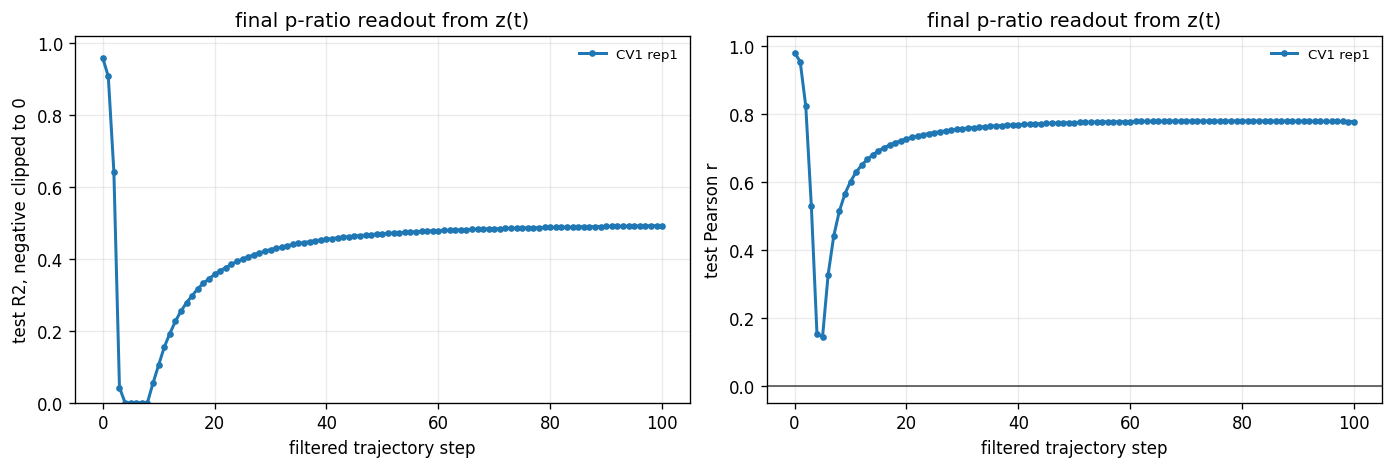

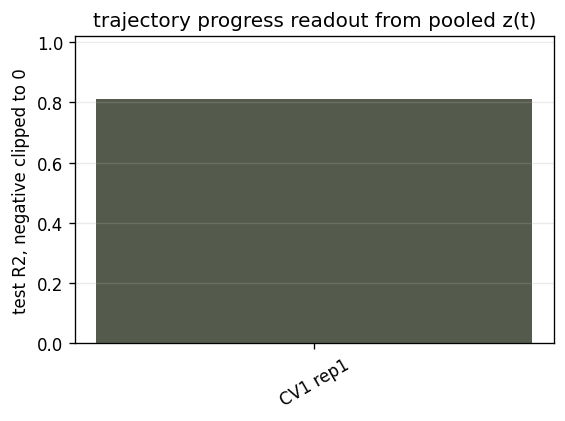

In [17]:
# Framewise latent readout tests.
# 1. For each trajectory step, fit val z(t) -> final p-ratio and evaluate on test z(t).
# 2. Pool frames, fit val z(t) -> normalized frame progress and evaluate on test frames.

framewise_max_steps = int(cfg.get('framewise_latent_max_steps', 100))
framewise_stride = int(cfg.get('framewise_latent_stride', 1))


def fit_linear_readout(train_X, train_y, test_X, test_y):
    train_X = np.asarray(train_X, dtype=float)
    train_y = np.asarray(train_y, dtype=float)
    test_X = np.asarray(test_X, dtype=float)
    test_y = np.asarray(test_y, dtype=float)
    finite_train = np.isfinite(train_y) & np.isfinite(train_X).all(axis=1)
    finite_test = np.isfinite(test_y) & np.isfinite(test_X).all(axis=1)
    train_X, train_y = train_X[finite_train], train_y[finite_train]
    test_X, test_y = test_X[finite_test], test_y[finite_test]
    if len(train_y) < train_X.shape[1] + 1 or len(test_y) < 3 or np.std(train_y) <= 0 or np.std(test_y) <= 0:
        return {'test_r2': np.nan, 'test_pearson': np.nan, 'test_mse': np.nan, 'n_train': len(train_y), 'n_test': len(test_y)}
    X = np.column_stack([np.ones(len(train_X)), train_X])
    beta = np.linalg.lstsq(X, train_y, rcond=None)[0]
    pred = np.column_stack([np.ones(len(test_X)), test_X]) @ beta
    return {
        'test_r2': r2_score(test_y, pred),
        'test_pearson': pearson_r(test_y, pred),
        'test_mse': float(np.mean((test_y - pred) ** 2)),
        'n_train': len(train_y),
        'n_test': len(test_y),
    }


def latent_frame_rows_for_split(result, sims, split_name, *, max_steps, stride):
    rows = []
    ae_model = result['ae']
    latent_dim = int(result['params']['latent_dim'])
    repeat_idx = int(result['params'].get('repeat_idx', 1))
    ae_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            frame_ids = filtered_frame_ids(sim, include_last=True)
            if len(frame_ids) <= 1:
                continue
            final_p_ratio = float(calc_p_ratio_rollout_sides(sim, -1))
            max_available_step = min(len(frame_ids) - 1, int(max_steps))
            steps = list(range(0, max_available_step + 1, max(1, int(stride))))
            if steps[-1] != max_available_step:
                steps.append(max_available_step)
            for filtered_step in steps:
                frame_idx = int(frame_ids[int(filtered_step)])
                z = encode_frame(ae_model, sim, frame_idx, device=device).detach().cpu().numpy().reshape(-1)
                row = {
                    'split': split_name,
                    'latent_dim': latent_dim,
                    'repeat_idx': repeat_idx,
                    'run_label': result['label'],
                    'sim_idx': int(sim_idx),
                    'frame_idx': frame_idx,
                    'filtered_step': int(filtered_step),
                    'frame_progress': float(filtered_step / max(len(frame_ids) - 1, 1)),
                    'final_p_ratio': final_p_ratio,
                }
                for dim_idx, value in enumerate(z):
                    row[f'z{dim_idx}'] = float(value)
                rows.append(row)
    return pd.DataFrame(rows)


framewise_latent_df = pd.concat([
    table
    for result_item in source_results
    for table in [
        latent_frame_rows_for_split(result_item, result_item['val_data'], 'val', max_steps=framewise_max_steps, stride=framewise_stride),
        latent_frame_rows_for_split(result_item, result_item['test_data'], 'test', max_steps=framewise_max_steps, stride=framewise_stride),
    ]
], ignore_index=True)
framewise_latent_df.to_csv(run_dir / 'framewise_latent_table.csv', index=False)

framewise_readout_rows = []
for (latent_dim, repeat_idx), group in framewise_latent_df.groupby(['latent_dim', 'repeat_idx']):
    z_cols = [col for col in group.columns if col.startswith('z') and group[col].notna().any()]
    if not z_cols:
        continue
    for filtered_step in sorted(group['filtered_step'].unique()):
        val_step = group[group['split'].eq('val') & group['filtered_step'].eq(filtered_step)]
        test_step = group[group['split'].eq('test') & group['filtered_step'].eq(filtered_step)]
        if val_step.empty or test_step.empty:
            continue
        metric = fit_linear_readout(
            val_step[z_cols].to_numpy(float),
            val_step['final_p_ratio'].to_numpy(float),
            test_step[z_cols].to_numpy(float),
            test_step['final_p_ratio'].to_numpy(float),
        )
        framewise_readout_rows.append({
            'latent_dim': int(latent_dim),
            'repeat_idx': int(repeat_idx),
            'readout': 'final_p_ratio_at_same_step',
            'filtered_step': int(filtered_step),
            **metric,
        })

progress_readout_rows = []
for (latent_dim, repeat_idx), group in framewise_latent_df.groupby(['latent_dim', 'repeat_idx']):
    z_cols = [col for col in group.columns if col.startswith('z') and group[col].notna().any()]
    val_rows = group[group['split'].eq('val')]
    test_rows = group[group['split'].eq('test')]
    metric = fit_linear_readout(
        val_rows[z_cols].to_numpy(float),
        val_rows['frame_progress'].to_numpy(float),
        test_rows[z_cols].to_numpy(float),
        test_rows['frame_progress'].to_numpy(float),
    )
    progress_readout_rows.append({
        'latent_dim': int(latent_dim),
        'repeat_idx': int(repeat_idx),
        'readout': 'frame_progress_pooled',
        'filtered_step': -1,
        **metric,
    })

framewise_readout_df = pd.DataFrame(framewise_readout_rows)
progress_readout_df = pd.DataFrame(progress_readout_rows)
framewise_readout_df.to_csv(run_dir / 'framewise_latent_final_p_ratio_readout.csv', index=False)
progress_readout_df.to_csv(run_dir / 'framewise_latent_progress_readout.csv', index=False)

print('framewise latent rows:', framewise_latent_df.shape)
print('progress readout, val fit -> test')
display(progress_readout_df.round(5))
print('final p-ratio readout by trajectory step, val fit -> test')
display(framewise_readout_df.round(5).head(20))

if not framewise_readout_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), constrained_layout=True)
    for (latent_dim, repeat_idx), group in framewise_readout_df.groupby(['latent_dim', 'repeat_idx']):
        group = group.sort_values('filtered_step')
        label = f'CV{int(latent_dim)} rep{int(repeat_idx)}'
        axes[0].plot(group['filtered_step'], group['test_r2'].clip(lower=0), marker='o', ms=3, lw=1.8, label=label)
        axes[1].plot(group['filtered_step'], group['test_pearson'], marker='o', ms=3, lw=1.8, label=label)
    axes[0].set_title('final p-ratio readout from z(t)')
    axes[0].set_xlabel('filtered trajectory step')
    axes[0].set_ylabel('test R2, negative clipped to 0')
    axes[0].set_ylim(0, 1.02)
    axes[1].set_title('final p-ratio readout from z(t)')
    axes[1].set_xlabel('filtered trajectory step')
    axes[1].set_ylabel('test Pearson r')
    axes[1].axhline(0, color='0.25', lw=0.9)
    for ax in axes:
        ax.legend(frameon=False, fontsize=8)
        ax.grid(alpha=0.25)
    plt.show()

if not progress_readout_df.empty:
    fig, ax = plt.subplots(figsize=(4.6, 3.4), constrained_layout=True)
    labels = [f"CV{int(r.latent_dim)} rep{int(r.repeat_idx)}" for r in progress_readout_df.itertuples()]
    ax.bar(labels, progress_readout_df['test_r2'].clip(lower=0), color='#545B4C')
    ax.set_ylabel('test R2, negative clipped to 0')
    ax.set_title('trajectory progress readout from pooled z(t)')
    ax.set_ylim(0, 1.02)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)
    plt.show()



## Rollout Diagnostics


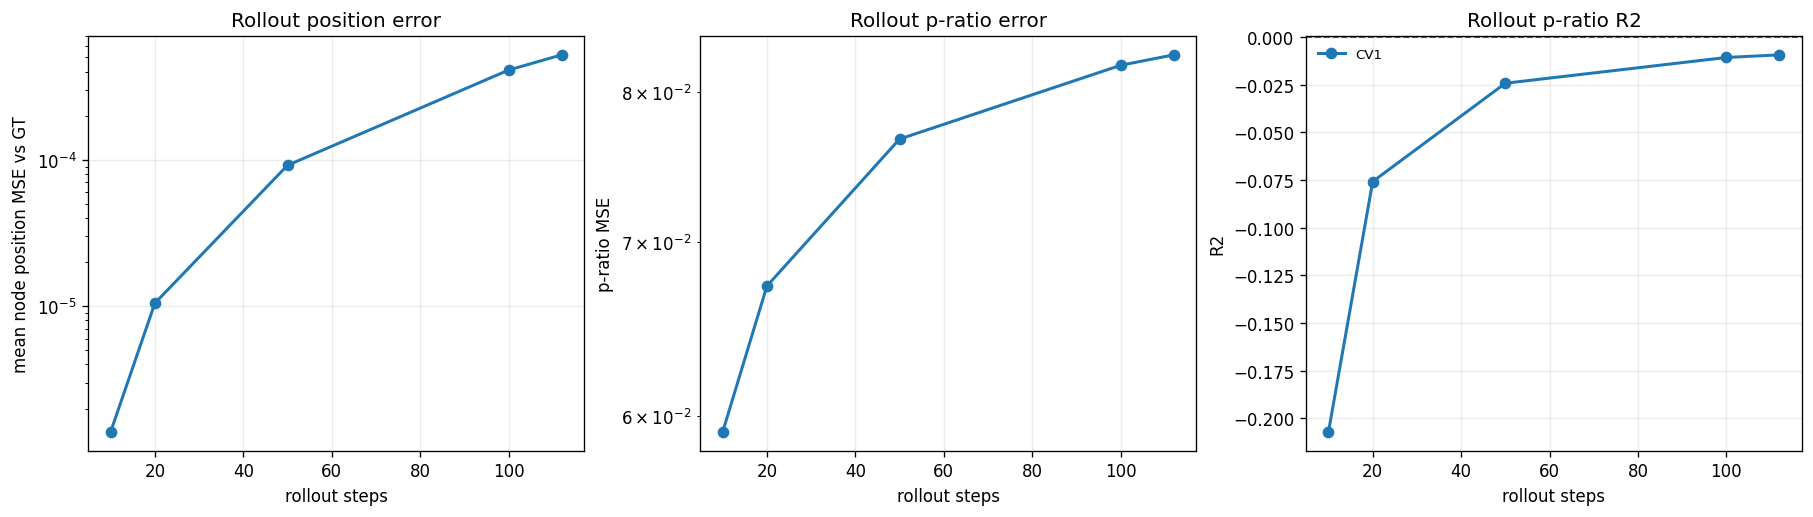

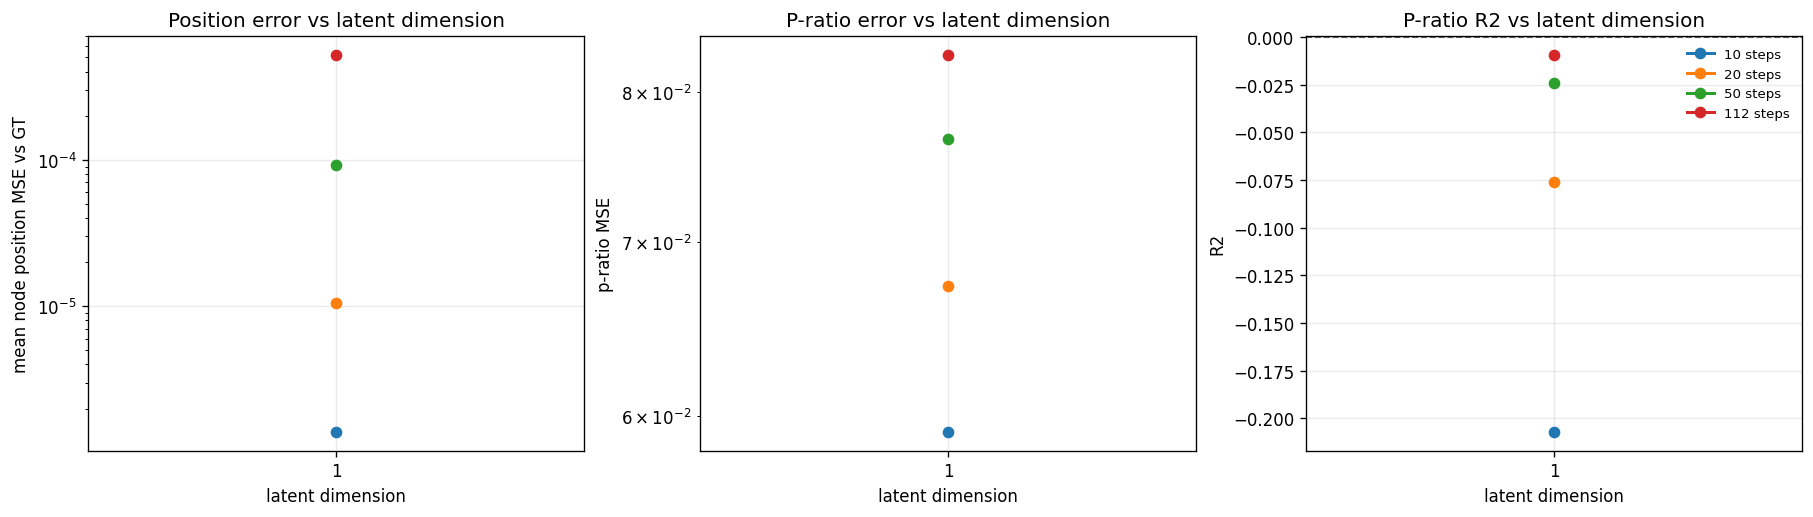

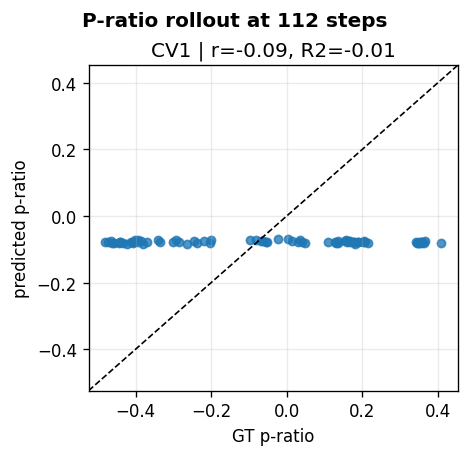

,latent_dim,split,rollout_steps,final_pos_mse,p_ratio_mse,used,p_ratio_r2,p_ratio_pearson
0,1,test,10,0.000001,0.059158,74,-0.207008,-0.027741
1,1,test,20,0.000010,0.067337,74,-0.075771,-0.012905
2,1,test,50,0.000092,0.076726,74,-0.024204,-0.052843
3,1,test,100,0.000410,0.081922,74,-0.010686,-0.087545
4,1,test,112,0.000521,0.082687,74,-0.009315,-0.094430


In [12]:
if rollout_rows_df.empty:
    print('No rollout rows available.')
else:
    curve_df = rollout_rows_df.copy()
    curve_df['p_ratio_sq_error'] = (curve_df['pred_p_ratio'] - curve_df['true_p_ratio']) ** 2
    repeat_curve_summary = curve_df.groupby(['latent_dim', 'repeat_idx', 'split', 'rollout_steps'], as_index=False).agg(
        final_pos_mse=('final_pos_mse', 'mean'),
        p_ratio_mse=('p_ratio_sq_error', 'mean'),
        used=('sim_idx', 'count'),
    )
    repeat_curve_summary.to_csv(run_dir / 'rollout_error_vs_steps_by_repeat.csv', index=False)
    curve_summary = curve_df.groupby(['latent_dim', 'split', 'rollout_steps'], as_index=False).agg(
        final_pos_mse=('final_pos_mse', 'mean'),
        p_ratio_mse=('p_ratio_sq_error', 'mean'),
        used=('sim_idx', 'count'),
    )
    r2_rows = []
    for (latent_dim, split_name, steps), group in curve_df.groupby(['latent_dim', 'split', 'rollout_steps']):
        r2_rows.append({
            'latent_dim': int(latent_dim),
            'split': split_name,
            'rollout_steps': int(steps),
            'p_ratio_r2': r2_score(group['true_p_ratio'], group['pred_p_ratio']),
            'p_ratio_pearson': pearson_r(group['true_p_ratio'], group['pred_p_ratio']),
        })
    curve_summary = curve_summary.merge(pd.DataFrame(r2_rows), on=['latent_dim', 'split', 'rollout_steps'], how='left')
    curve_summary.to_csv(run_dir / 'rollout_error_vs_steps.csv', index=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
    plot_curve = curve_summary[curve_summary['split'].eq('test')].copy()
    for latent_dim, group in plot_curve.groupby('latent_dim'):
        group = group.sort_values('rollout_steps')
        label = f'CV{int(latent_dim)}'
        axes[0].plot(group['rollout_steps'], group['final_pos_mse'], marker='o', lw=1.8, label=label)
        axes[1].plot(group['rollout_steps'], group['p_ratio_mse'], marker='o', lw=1.8, label=label)
        axes[2].plot(group['rollout_steps'], group['p_ratio_r2'], marker='o', lw=1.8, label=label)
    axes[0].set_title('Rollout position error')
    axes[0].set_xlabel('rollout steps')
    axes[0].set_ylabel('mean node position MSE vs GT')
    axes[0].set_yscale('log')
    axes[0].grid(alpha=0.25)
    axes[1].set_title('Rollout p-ratio error')
    axes[1].set_xlabel('rollout steps')
    axes[1].set_ylabel('p-ratio MSE')
    axes[1].set_yscale('log')
    axes[1].grid(alpha=0.25)
    axes[2].set_title('Rollout p-ratio R2')
    axes[2].set_xlabel('rollout steps')
    axes[2].set_ylabel('R2')
    axes[2].axhline(0, color='0.25', lw=1.0, ls='--')
    axes[2].grid(alpha=0.25)
    axes[2].legend(frameon=False, fontsize=8)
    fig.savefig(run_dir / 'rollout_error_vs_steps.png', dpi=200, bbox_inches='tight')
    plt.show()

    test_curve = curve_summary[curve_summary['split'].eq('test')].copy()
    available_steps = sorted(test_curve['rollout_steps'].dropna().astype(int).unique())
    if available_steps:
        step_indices = np.linspace(0, len(available_steps) - 1, min(4, len(available_steps)), dtype=int)
        selected_steps_for_dim_plot = [available_steps[int(idx)] for idx in step_indices]
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
        for steps in selected_steps_for_dim_plot:
            group = test_curve[test_curve['rollout_steps'].eq(steps)].sort_values('latent_dim')
            label = f'{int(steps)} steps'
            axes[0].plot(group['latent_dim'], group['final_pos_mse'], marker='o', lw=1.8, label=label)
            axes[1].plot(group['latent_dim'], group['p_ratio_mse'], marker='o', lw=1.8, label=label)
            axes[2].plot(group['latent_dim'], group['p_ratio_r2'], marker='o', lw=1.8, label=label)
        for ax in axes:
            ax.set_xlabel('latent dimension')
            ax.set_xticks(sorted(test_curve['latent_dim'].dropna().astype(int).unique()))
            ax.grid(alpha=0.25)
        axes[0].set_title('Position error vs latent dimension')
        axes[0].set_ylabel('mean node position MSE vs GT')
        axes[0].set_yscale('log')
        axes[1].set_title('P-ratio error vs latent dimension')
        axes[1].set_ylabel('p-ratio MSE')
        axes[1].set_yscale('log')
        axes[2].set_title('P-ratio R2 vs latent dimension')
        axes[2].set_ylabel('R2')
        axes[2].axhline(0, color='0.25', lw=1.0, ls='--')
        axes[2].legend(frameon=False, fontsize=8)
        fig.savefig(run_dir / 'rollout_error_summary.png', dpi=200, bbox_inches='tight')
        plt.show()

    available_steps = sorted(curve_df['rollout_steps'].dropna().astype(int).unique())
    if cfg.get('summary_rollout_step', 'max') == 'max':
        chosen_step = max(available_steps)
    else:
        chosen_step = min(available_steps, key=lambda s: abs(s - int(cfg['summary_rollout_step'])))
    scatter_df = curve_df[curve_df['rollout_steps'].eq(chosen_step) & curve_df['split'].eq('test')].copy()
    latent_order = sorted(scatter_df['latent_dim'].dropna().astype(int).unique())
    fig, axes = plt.subplots(1, len(latent_order), figsize=(3.8 * len(latent_order), 3.7), squeeze=False, constrained_layout=True)
    all_vals = np.concatenate([scatter_df['true_p_ratio'].to_numpy(float), scatter_df['pred_p_ratio'].to_numpy(float)])
    lo = float(np.nanmin(all_vals))
    hi = float(np.nanmax(all_vals))
    pad = 0.05 * max(hi - lo, 1e-6)
    for ax, latent_dim in zip(axes.ravel(), latent_order):
        sub = scatter_df[scatter_df['latent_dim'].eq(latent_dim)]
        x = sub['true_p_ratio'].to_numpy(float)
        y = sub['pred_p_ratio'].to_numpy(float)
        r = pearson_r(x, y)
        r2 = r2_score(x, y)
        ax.scatter(x, y, s=24, alpha=0.78)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1.0)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f'CV{latent_dim} | r={r:.2f}, R2={r2:.2f}')
        ax.set_xlabel('GT p-ratio')
        ax.set_ylabel('predicted p-ratio')
        ax.grid(alpha=0.25)
    fig.suptitle(f'P-ratio rollout at {chosen_step} steps', fontweight='bold')
    fig.savefig(run_dir / 'rollout_p_ratio_pred_vs_gt.png', dpi=200, bbox_inches='tight')
    plt.show()

    display(curve_summary.round(6))



